# Ioannina DC Detailed Cashflows — Analysis Notebook

This notebook is built from `ioannina_dc_strategy_detailed_cashflows.py` and produces charts in the same style as `00_prototype.ipynb`.

It focuses on:
- scenario and decision summaries
- Monte Carlo risk distributions
- one-way sensitivity visuals
- detailed annual cashflow operating profiles
- qualitative risk review

In [2]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == 'notebooks' else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import ioannina_dc_strategy_detailed_cashflows as dc

dc = importlib.reload(dc)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
pd.options.display.float_format = lambda x: f'{x:,.2f}'

PROJECT_DISCOUNT_RATE = 0.08
EQUITY_DISCOUNT_RATE = 0.12
OPERATING_YEARS = 15

ga = dc.GlobalAssumptions(
    discount_rate_project=PROJECT_DISCOUNT_RATE,
    discount_rate_equity=EQUITY_DISCOUNT_RATE,
    iterations=2000,
    random_seed=42,
)
strategies = dc.make_strategies()
for strategy in strategies.values():
    strategy.op_years = OPERATING_YEARS
    if strategy.sale_year_index is not None:
        strategy.sale_year_index = OPERATING_YEARS
scenarios = dc.make_scenarios()

summary_rows = []
annual_tables = {}
mc_runs = {}
mc_rows = []
decision_rows = []
sensitivity_map = {}

for strategy in strategies.values():
    downside_summary = None
    upside_summary = None

    for scenario in scenarios.values():
        detailed = dc.build_detailed_cashflows(strategy, ga, scenario)
        annual_tables[(strategy.name, scenario.name)] = detailed['annual_table']
        summary = dc.summarize_strategy(strategy, ga, scenario)
        summary_rows.append(summary)
        if scenario.name == 'Downside':
            downside_summary = summary
        elif scenario.name == 'Upside':
            upside_summary = summary

    mc_df = dc.monte_carlo(strategy, ga)
    mc_runs[strategy.name] = mc_df
    mc_summary = dc.summarize_mc(mc_df, ga.hurdle_equity_irr)
    mc_rows.append({'Strategy': strategy.name, **mc_summary})
    decision_rows.append(dc.score_option(strategy, downside_summary['Project_NPV_9pct'], upside_summary['Equity_IRR'], mc_summary))
    sensitivity_map[strategy.name] = dc.one_way_sensitivity(strategy, ga, scenarios['Base'])

scenario_df = pd.DataFrame(summary_rows)
mc_summary_df = pd.DataFrame(mc_rows)
decision_df = pd.DataFrame(decision_rows).sort_values('Weighted_Score_100', ascending=False)
strategy_order = decision_df['Strategy'].tolist()
best = decision_df.iloc[0]

display(Markdown(
    f"**Assumptions:** project discount rate `{ga.discount_rate_project:.0%}`, "
    f"equity discount rate `{ga.discount_rate_equity:.0%}`, "
    f"operating horizon `{OPERATING_YEARS}` years."
))
display(Markdown(f"## Recommendation snapshot\n**Best option now:** `{best['Strategy']}` with weighted score **{best['Weighted_Score_100']:.1f}/100**."))
display(Markdown('### Scenario summary'))
display(scenario_df)
display(Markdown('### Monte Carlo summary'))
display(mc_summary_df)
display(Markdown('### Decision matrix'))
display(decision_df)

**Assumptions:** project discount rate `8%`, equity discount rate `12%`, operating horizon `15` years.

## Recommendation snapshot
**Best option now:** `Powered Shell` with weighted score **74.0/100**.

### Scenario summary

,Strategy,Scenario,TDC_EUR,Rent_EUR_per_kW_month,Exit_Yield,Project_NPV_9pct,Equity_NPV_13pct,Project_IRR,Equity_IRR,Min_DSCR,Stabilized_NOI,Terminal_or_Sale_Value,Break_even_Rent_EUR_per_kW_month,Break_even_Stabilized_Occupancy
0,Turnkey,Base,"119,000,000.00",90.00,0.07,"28,709,474.07","6,428,777.15",0.10,0.13,0.51,"14,125,961.80","200,503,862.34",74.50,0.77
1,Turnkey,Downside,"128,520,000.00",82.80,0.08,"-10,793,139.51","-23,138,096.12",0.07,0.08,0.29,"11,712,826.59","149,593,329.99",97.07,0.99
2,Turnkey,Upside,"115,430,000.00",97.20,0.06,"57,302,647.96","26,536,572.48",0.12,0.16,0.66,"16,022,039.23","245,634,703.60",63.15,0.63
3,Powered Shell,Base,"57,000,000.00",52.00,0.07,"21,463,614.88","7,450,283.98",0.11,0.14,0.35,"8,185,216.38","104,564,541.81",39.47,0.69
4,Powered Shell,Downside,"61,560,000.00",47.84,0.08,"922,253.13","-7,863,282.22",0.08,0.09,0.15,"6,792,844.45","78,871,307.12",51.35,0.93
5,Powered Shell,Upside,"55,290,000.00",56.16,0.07,"36,314,991.25","17,880,640.33",0.13,0.18,0.50,"9,280,256.79","127,033,975.41",33.54,0.57
6,Build-to-exit,Base,"62,000,000.00",57.00,0.07,"22,221,159.83","7,580,409.44",0.11,0.14,0.39,"8,404,928.39","111,066,709.12",43.84,0.67
7,Build-to-exit,Downside,"66,960,000.00",52.44,0.08,"-241,280.90","-9,193,496.72",0.08,0.09,0.18,"6,919,930.55","82,850,197.08",57.17,0.99
8,Build-to-exit,Upside,"60,140,000.00",61.56,0.07,"38,456,396.61","19,006,342.66",0.13,0.18,0.54,"9,562,456.30","135,737,782.97",37.22,0.55


### Monte Carlo summary

,Strategy,NPV_P10,NPV_P50,NPV_P90,EqIRR_P10,EqIRR_P50,EqIRR_P90,Prob_NPV_lt_0,Prob_EqIRR_lt_Hurdle
0,Turnkey,"9,557,592.32","21,665,947.57","32,471,435.50",0.11,0.12,0.13,0.01,1.00
1,Powered Shell,"13,160,284.45","19,442,470.28","25,063,635.61",0.12,0.14,0.15,0.00,0.86
2,Build-to-exit,"7,247,042.82","14,934,295.53","21,570,613.05",0.11,0.13,0.14,0.01,0.98


### Decision matrix

,Strategy,Weighted_Score_100,score_risk_adjusted_return,score_downside_resilience,score_absolute_upside,score_bankability_without_anchor,score_bankability_with_anchor,score_fit_with_ioannina,score_optionality,score_exit_sensitivity
1,Powered Shell,74.00,2,5,3,3,3,5,5,4
2,Build-to-exit,52.00,2,3,3,2,4,3,3,1
0,Turnkey,50.00,2,2,3,2,5,2,2,3


## Scenario, risk, and cashflow charts

These visuals mirror the style of the prototype notebook while using the detailed Ioannina data-center cashflow model.

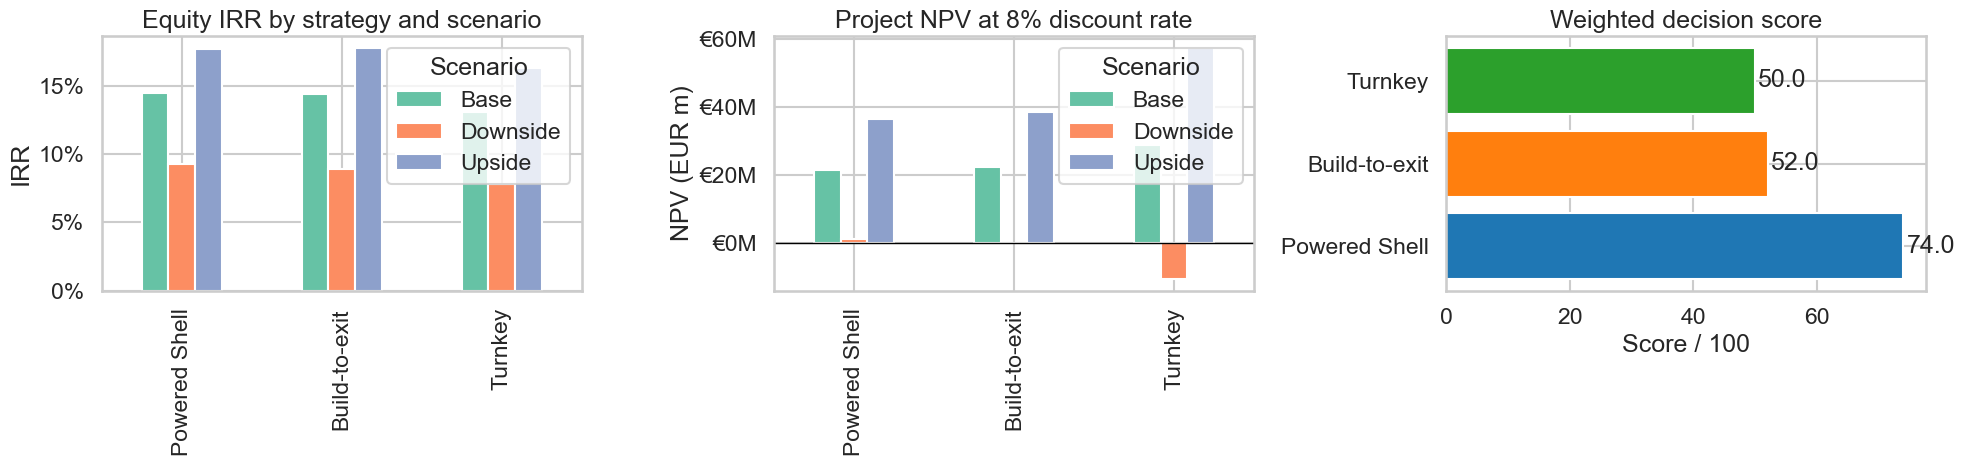

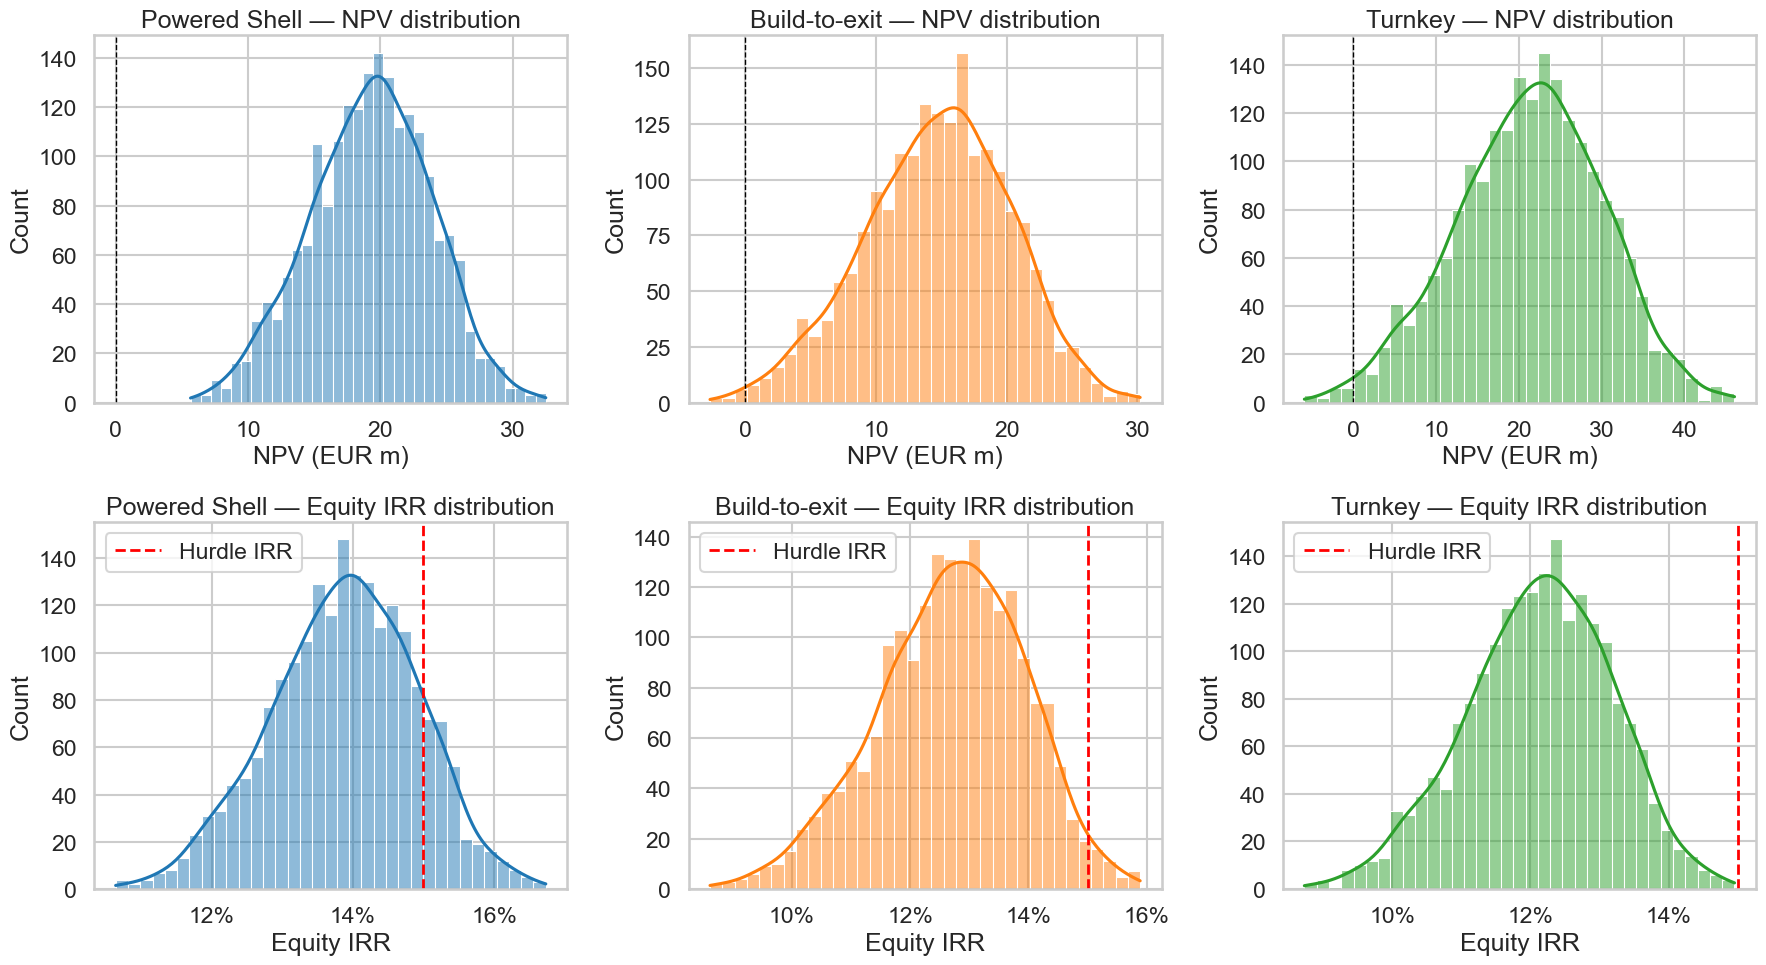

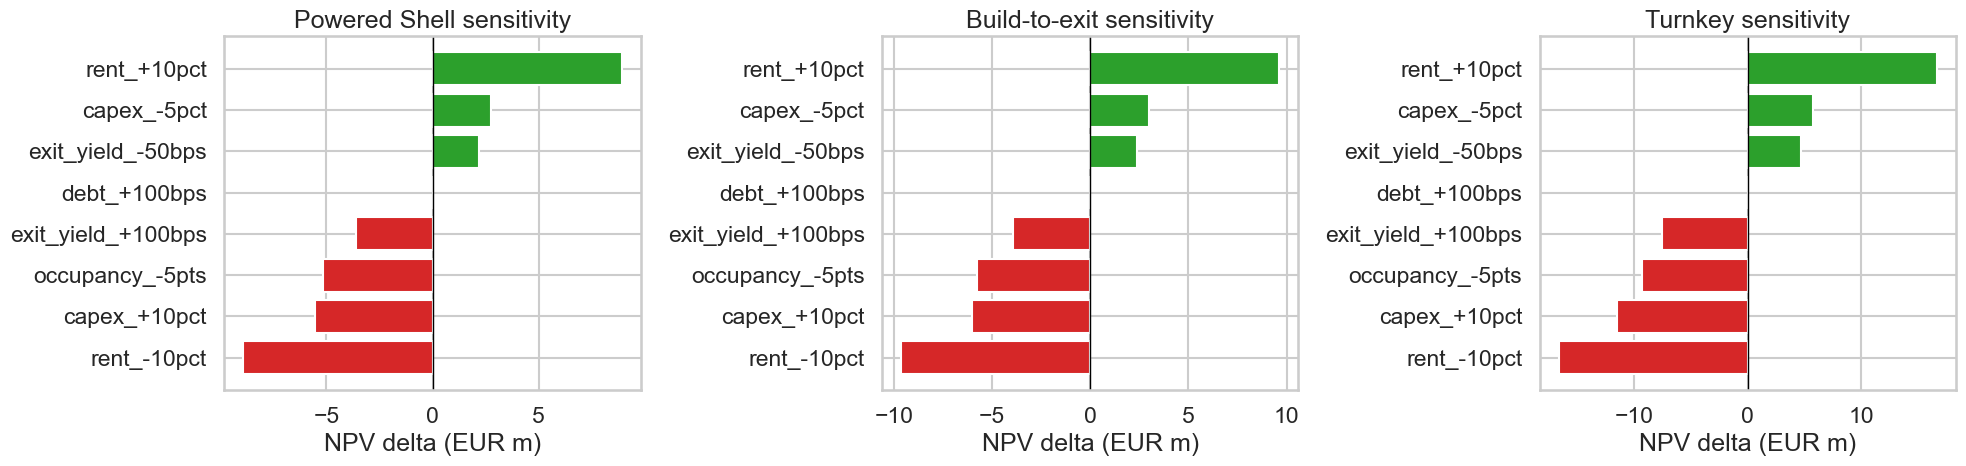

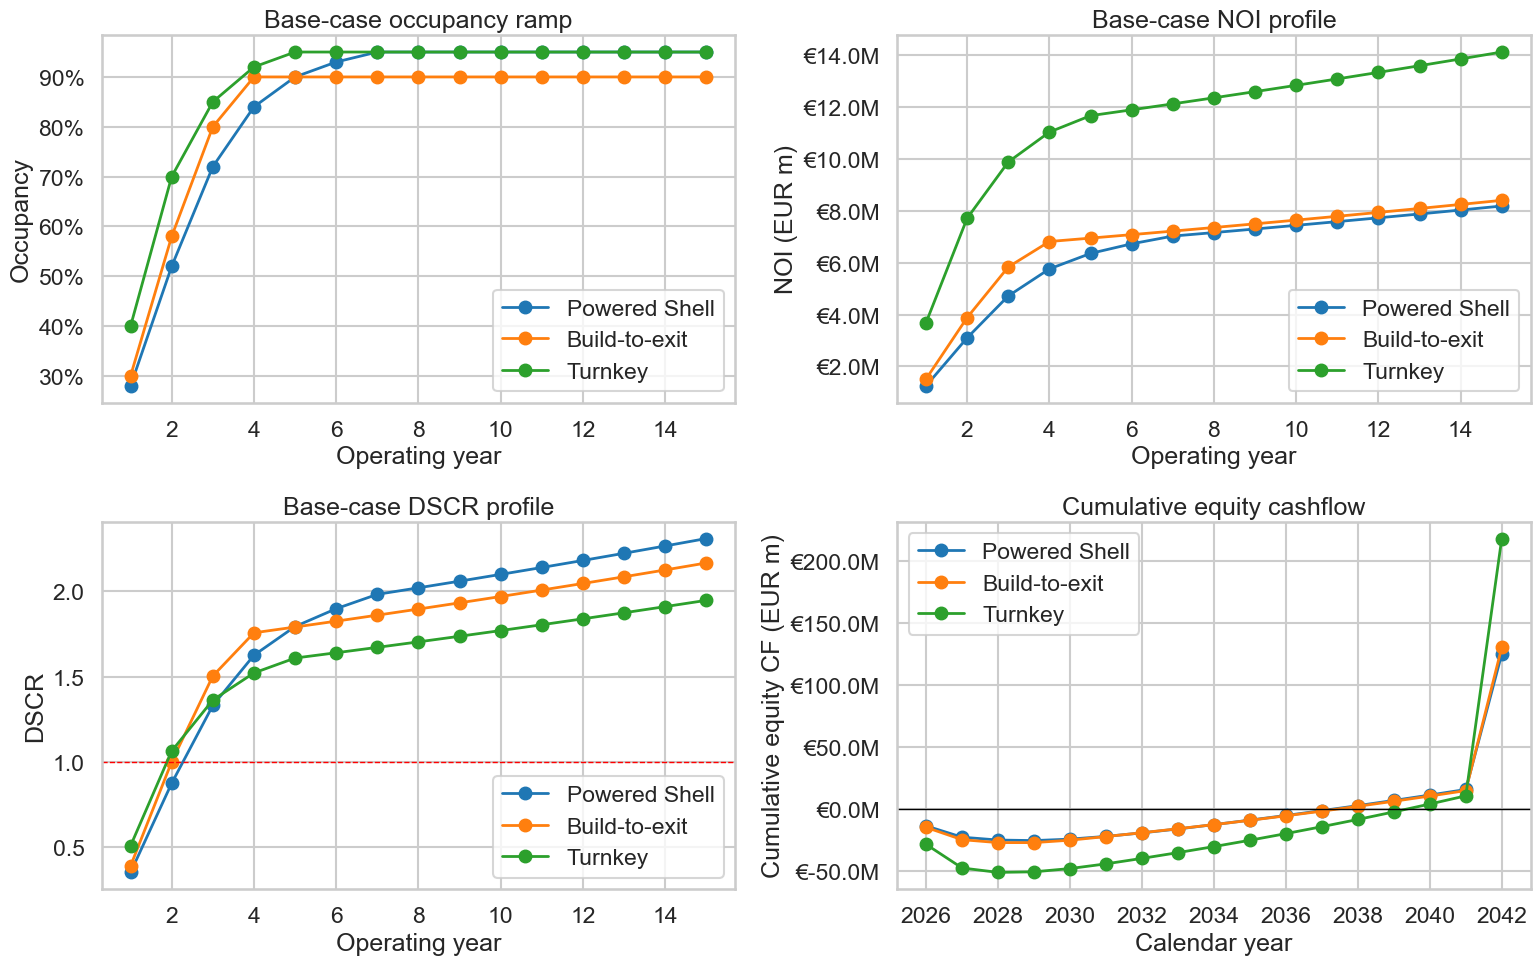

In [3]:
scenario_order = ['Base', 'Downside', 'Upside']
scenario_colors = sns.color_palette('Set2', 3)
series_colors = dict(zip(strategy_order, sns.color_palette('tab10', len(strategy_order))))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

irr_pivot = scenario_df.pivot(index='Strategy', columns='Scenario', values='Equity_IRR').reindex(strategy_order)[scenario_order]
irr_pivot.plot(kind='bar', ax=axes[0], color=scenario_colors)
axes[0].set_title('Equity IRR by strategy and scenario')
axes[0].set_xlabel('')
axes[0].set_ylabel('IRR')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(title='Scenario')

npv_pivot = (scenario_df.pivot(index='Strategy', columns='Scenario', values='Project_NPV_9pct').reindex(strategy_order)[scenario_order] / 1e6)
npv_pivot.plot(kind='bar', ax=axes[1], color=scenario_colors)
axes[1].set_title(f'Project NPV at {ga.discount_rate_project:.0%} discount rate')
axes[1].set_xlabel('')
axes[1].set_ylabel('NPV (EUR m)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'€{y:,.0f}M'))
axes[1].legend(title='Scenario')

axes[2].barh(decision_df['Strategy'], decision_df['Weighted_Score_100'], color=[series_colors[s] for s in decision_df['Strategy']])
for idx, value in enumerate(decision_df['Weighted_Score_100']):
    axes[2].text(value + 0.5, idx, f'{value:.1f}', va='center')
axes[2].set_title('Weighted decision score')
axes[2].set_xlabel('Score / 100')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, name in enumerate(strategy_order):
    mc_df = mc_runs[name]
    color = series_colors[name]

    sns.histplot(mc_df['npv'] / 1e6, bins=35, kde=True, ax=axes[0, col], color=color)
    axes[0, col].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0, col].set_title(f'{name} — NPV distribution')
    axes[0, col].set_xlabel('NPV (EUR m)')
    axes[0, col].set_ylabel('Count')

    sns.histplot(mc_df['equity_irr'], bins=35, kde=True, ax=axes[1, col], color=color)
    axes[1, col].axvline(ga.hurdle_equity_irr, color='red', linestyle='--', linewidth=2, label='Hurdle IRR')
    axes[1, col].set_title(f'{name} — Equity IRR distribution')
    axes[1, col].set_xlabel('Equity IRR')
    axes[1, col].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[1, col].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, name in zip(axes, strategy_order):
    sens = sensitivity_map[name].copy()
    sens['npv_delta_m'] = sens['npv_delta'] / 1e6
    colors = ['#d62728' if x < 0 else '#2ca02c' for x in sens['npv_delta_m']]
    ax.barh(sens['variable'], sens['npv_delta_m'], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{name} sensitivity')
    ax.set_xlabel('NPV delta (EUR m)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for name in strategy_order:
    base_annual = annual_tables[(name, 'Base')]
    ops = base_annual[base_annual['phase'] == 'Operate']
    color = series_colors[name]

    axes[0, 0].plot(ops['op_year'], ops['occupancy'], marker='o', linewidth=2, label=name, color=color)
    axes[0, 1].plot(ops['op_year'], ops['noi'] / 1e6, marker='o', linewidth=2, label=name, color=color)
    axes[1, 0].plot(ops['op_year'], ops['dscr'], marker='o', linewidth=2, label=name, color=color)
    axes[1, 1].plot(base_annual['calendar_year'], base_annual['cum_equity_cf'] / 1e6, marker='o', linewidth=2, label=name, color=color)

axes[0, 0].set_title('Base-case occupancy ramp')
axes[0, 0].set_xlabel('Operating year')
axes[0, 0].set_ylabel('Occupancy')
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0, 0].legend()

axes[0, 1].set_title('Base-case NOI profile')
axes[0, 1].set_xlabel('Operating year')
axes[0, 1].set_ylabel('NOI (EUR m)')
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'€{y:.1f}M'))
axes[0, 1].legend()

axes[1, 0].set_title('Base-case DSCR profile')
axes[1, 0].set_xlabel('Operating year')
axes[1, 0].set_ylabel('DSCR')
axes[1, 0].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[1, 0].legend()

axes[1, 1].set_title('Cumulative equity cashflow')
axes[1, 1].set_xlabel('Calendar year')
axes[1, 1].set_ylabel('Cumulative equity CF (EUR m)')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'€{y:.1f}M'))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [4]:
display(Markdown('## Detailed annual tables and risk register'))
display(dc.make_risk_register())

for name in strategy_order:
    display(Markdown(f'### {name} — Base scenario annual cashflows'))
    display(annual_tables[(name, 'Base')])

## Detailed annual tables and risk register

,Risk,Most_Exposed_Option,Why_It_Matters,Mitigation
0,Lease-up delay,Turnkey / Build-to-exit,Ioannina has less public multi-MW absorption e...,"Anchor-first marketing, phased scope release"
1,Pricing miss,Turnkey,Higher rent hurdle needed to justify fit-out c...,Do not spec-fit without tenant visibility
2,Exit-yield widening,Build-to-exit,Sale thesis is sensitive to buyer pricing,Underwrite hold as fallback
3,Bankability / leverage,Powered Shell / Build-to-exit,Speculative income profile may need lower leve...,Model lower leverage until pre-let
4,Scope mismatch,Turnkey,Wrong fit-out design can trap capex,Keep base design modular
5,Counterparty weakness,Build-to-exit / Powered Shell,Secondary-city occupier pool may be weaker,"Guarantees, deposits, covenants"
6,Power / schedule slip,All,July 2027 target still carries execution risk,Utility milestones and float
7,Thin buyer pool,Build-to-exit,Ioannina is not a proven prime exit market,Do not force a sale date
8,Under-monetization,Powered Shell,Too conservative if a strong anchor appears,Pre-engineer turnkey conversion


### Powered Shell — Base scenario annual cashflows

,strategy,scenario,phase,period_index,calendar_year,build_year,op_year,occupancy,it_kw,rent_eur_per_kw_month,...,terminal_or_sale_value,project_cashflow,equity_cashflow,dscr,discount_factor_project,discount_factor_equity,discounted_project_cf,discounted_equity_cf,cum_project_cf,cum_equity_cf
0,Powered Shell,Base,Build,0,2026,1.00,NaN,0.00,"12,000.00",52.00,...,0.00,"-34,200,000.00","-13,680,000.00",NaN,1.00,1.00,"-34,200,000.00","-13,680,000.00","-34,200,000.00","-13,680,000.00"
1,Powered Shell,Base,Build,1,2027,2.00,NaN,0.00,"12,000.00",52.00,...,0.00,"-22,800,000.00","-9,120,000.00",NaN,0.93,0.89,"-21,111,111.11","-8,142,857.14","-57,000,000.00","-22,800,000.00"
2,Powered Shell,Base,Operate,2,2028,NaN,1.00,0.28,"12,000.00",52.00,...,0.00,"1,246,640.00","-2,297,730.77",0.35,0.86,0.80,"1,068,792.87","-1,831,736.90","-55,753,360.00","-25,097,730.77"
3,Powered Shell,Base,Operate,3,2029,NaN,2.00,0.52,"12,000.00",52.00,...,0.00,"3,100,385.20","-443,985.57",0.87,0.79,0.71,"2,461,185.73","-316,020.16","-52,652,974.80","-25,541,716.33"
4,Powered Shell,Base,Operate,4,2030,NaN,3.00,0.72,"12,000.00",52.00,...,0.00,"4,716,139.69","1,171,768.93",1.33,0.74,0.64,"3,466,503.47","744,680.34","-47,936,835.11","-24,369,947.41"
5,Powered Shell,Base,Operate,5,2031,NaN,4.00,0.84,"12,000.00",52.00,...,0.00,"5,759,556.39","2,215,185.62",1.62,0.68,0.57,"3,919,857.30","1,256,955.81","-42,177,278.71","-22,154,761.78"
6,Powered Shell,Base,Operate,6,2032,NaN,5.00,0.90,"12,000.00",52.00,...,0.00,"6,356,485.86","2,812,115.09",1.79,0.63,0.51,"4,005,664.32","1,424,705.02","-35,820,792.86","-19,342,646.70"
7,Powered Shell,Base,Operate,7,2033,NaN,6.00,0.93,"12,000.00",52.00,...,0.00,"6,726,945.08","3,182,574.31",1.90,0.58,0.45,"3,925,107.84","1,439,634.99","-29,093,847.78","-16,160,072.38"
8,Powered Shell,Base,Operate,8,2034,NaN,7.00,0.95,"12,000.00",52.00,...,0.00,"7,025,329.58","3,480,958.81",1.98,0.54,0.40,"3,795,566.98","1,405,900.88","-22,068,518.20","-12,679,113.57"
9,Powered Shell,Base,Operate,9,2035,NaN,8.00,0.95,"12,000.00",52.00,...,0.00,"7,160,907.47","3,616,536.71",2.02,0.50,0.36,"3,582,236.57","1,304,159.39","-14,907,610.72","-9,062,576.86"


### Build-to-exit — Base scenario annual cashflows

,strategy,scenario,phase,period_index,calendar_year,build_year,op_year,occupancy,it_kw,rent_eur_per_kw_month,...,terminal_or_sale_value,project_cashflow,equity_cashflow,dscr,discount_factor_project,discount_factor_equity,discounted_project_cf,discounted_equity_cf,cum_project_cf,cum_equity_cf
0,Build-to-exit,Base,Build,0,2026,1.00,NaN,0.00,"12,000.00",57.00,...,0.00,"-37,200,000.00","-14,880,000.00",NaN,1.00,1.00,"-37,200,000.00","-14,880,000.00","-37,200,000.00","-14,880,000.00"
1,Build-to-exit,Base,Build,1,2027,2.00,NaN,0.00,"12,000.00",57.00,...,0.00,"-24,800,000.00","-9,920,000.00",NaN,0.93,0.89,"-22,962,962.96","-8,857,142.86","-62,000,000.00","-24,800,000.00"
2,Build-to-exit,Base,Operate,2,2028,NaN,1.00,0.30,"12,000.00",57.00,...,0.00,"1,512,400.00","-2,368,024.49",0.39,0.86,0.80,"1,296,639.23","-1,887,774.63","-60,487,600.00","-27,168,024.49"
3,Build-to-exit,Base,Operate,3,2029,NaN,2.00,0.58,"12,000.00",57.00,...,0.00,"3,882,102.80","1,678.31",1.00,0.79,0.71,"3,081,738.37","1,194.59","-56,605,497.20","-27,166,346.19"
4,Build-to-exit,Base,Operate,4,2030,NaN,3.00,0.80,"12,000.00",57.00,...,0.00,"5,833,588.81","1,953,164.32",1.50,0.74,0.64,"4,287,861.92","1,241,271.23","-50,771,908.39","-25,213,181.87"
5,Build-to-exit,Base,Operate,5,2031,NaN,4.00,0.90,"12,000.00",57.00,...,0.00,"6,816,309.64","2,935,885.15",1.76,0.68,0.57,"4,639,065.81","1,665,900.08","-43,955,598.75","-22,277,296.72"
6,Build-to-exit,Base,Operate,6,2032,NaN,5.00,0.90,"12,000.00",57.00,...,0.00,"6,947,520.61","3,067,096.11",1.79,0.63,0.51,"4,378,116.47","1,553,886.34","-37,008,078.14","-19,210,200.60"
7,Build-to-exit,Base,Operate,7,2033,NaN,6.00,0.90,"12,000.00",57.00,...,0.00,"7,081,227.91","3,200,803.41",1.82,0.58,0.45,"4,131,828.47","1,447,880.91","-29,926,850.23","-16,009,397.19"
8,Build-to-exit,Base,Operate,8,2034,NaN,7.00,0.90,"12,000.00",57.00,...,0.00,"7,217,478.28","3,337,053.78",1.86,0.54,0.40,"3,899,378.94","1,347,780.05","-22,709,371.96","-12,672,343.41"
9,Build-to-exit,Base,Operate,9,2035,NaN,8.00,0.90,"12,000.00",57.00,...,0.00,"7,356,319.30","3,475,894.81",1.90,0.50,0.36,"3,679,991.13","1,253,442.51","-15,353,052.66","-9,196,448.60"


### Turnkey — Base scenario annual cashflows

,strategy,scenario,phase,period_index,calendar_year,build_year,op_year,occupancy,it_kw,rent_eur_per_kw_month,...,terminal_or_sale_value,project_cashflow,equity_cashflow,dscr,discount_factor_project,discount_factor_equity,discounted_project_cf,discounted_equity_cf,cum_project_cf,cum_equity_cf
0,Turnkey,Base,Build,0,2026,1.00,NaN,0.00,"12,000.00",90.00,...,0.00,"-71,400,000.00","-28,560,000.00",NaN,1.00,1.00,"-71,400,000.00","-28,560,000.00","-71,400,000.00","-28,560,000.00"
1,Turnkey,Base,Build,1,2027,2.00,NaN,0.00,"12,000.00",90.00,...,0.00,"-47,600,000.00","-19,040,000.00",NaN,0.93,0.89,"-44,074,074.07","-17,000,000.00","-119,000,000.00","-47,600,000.00"
2,Turnkey,Base,Operate,2,2028,NaN,1.00,0.40,"12,000.00",90.00,...,0.00,"3,684,000.00","-3,571,774.98",0.51,0.86,0.80,"3,158,436.21","-2,847,397.14","-115,316,000.00","-51,171,774.98"
3,Turnkey,Base,Operate,3,2029,NaN,2.00,0.70,"12,000.00",90.00,...,0.00,"7,715,940.00","460,165.02",1.06,0.79,0.71,"6,125,161.94","327,536.37","-107,600,060.00","-50,711,609.95"
4,Turnkey,Base,Operate,4,2030,NaN,3.00,0.85,"12,000.00",90.00,...,0.00,"9,885,108.90","2,629,333.92",1.36,0.74,0.64,"7,265,850.14","1,670,989.24","-97,714,951.10","-48,082,276.03"
5,Turnkey,Base,Operate,5,2031,NaN,4.00,0.92,"12,000.00",90.00,...,0.00,"11,037,659.29","3,781,884.31",1.52,0.68,0.57,"7,512,045.45","2,145,942.72","-86,677,291.81","-44,300,391.72"
6,Turnkey,Base,Operate,6,2032,NaN,5.00,0.95,"12,000.00",90.00,...,0.00,"11,671,185.42","4,415,410.44",1.61,0.63,0.51,"7,354,826.56","2,236,984.34","-75,006,106.39","-39,884,981.27"
7,Turnkey,Base,Operate,7,2033,NaN,6.00,0.95,"12,000.00",90.00,...,0.00,"11,896,330.53","4,640,555.55",1.64,0.58,0.45,"6,941,394.60","2,099,151.66","-63,109,775.86","-35,244,425.72"
8,Turnkey,Base,Operate,8,2034,NaN,7.00,0.95,"12,000.00",90.00,...,0.00,"12,125,771.58","4,869,996.60",1.67,0.54,0.40,"6,551,177.08","1,966,909.95","-50,984,004.29","-30,374,429.12"
9,Turnkey,Base,Operate,9,2035,NaN,8.00,0.95,"12,000.00",90.00,...,0.00,"12,359,589.31","5,103,814.33",1.70,0.50,0.36,"6,182,871.79","1,840,486.61","-38,624,414.98","-25,270,614.79"


Extended prototype-style visualization functions loaded for the detailed cashflow notebook.
Available helpers:
 - plot_cashflow_scenarios
 - plot_monte_carlo_npv_distribution
 - plot_monte_carlo_irr_payback
 - plot_input_distributions
 - plot_npv_vs_key_drivers
 - calculate_breakeven_table
 - plot_breakeven_analysis
 - plot_cumulative_cashflows
 - plot_revenue_cost_breakdown
 - plot_risk_heatmap
 - plot_npv_probability_zones
 - plot_scenario_comparison_table
 - plot_monte_carlo_summary_stats
Generating extended prototype-style visuals for: Powered Shell


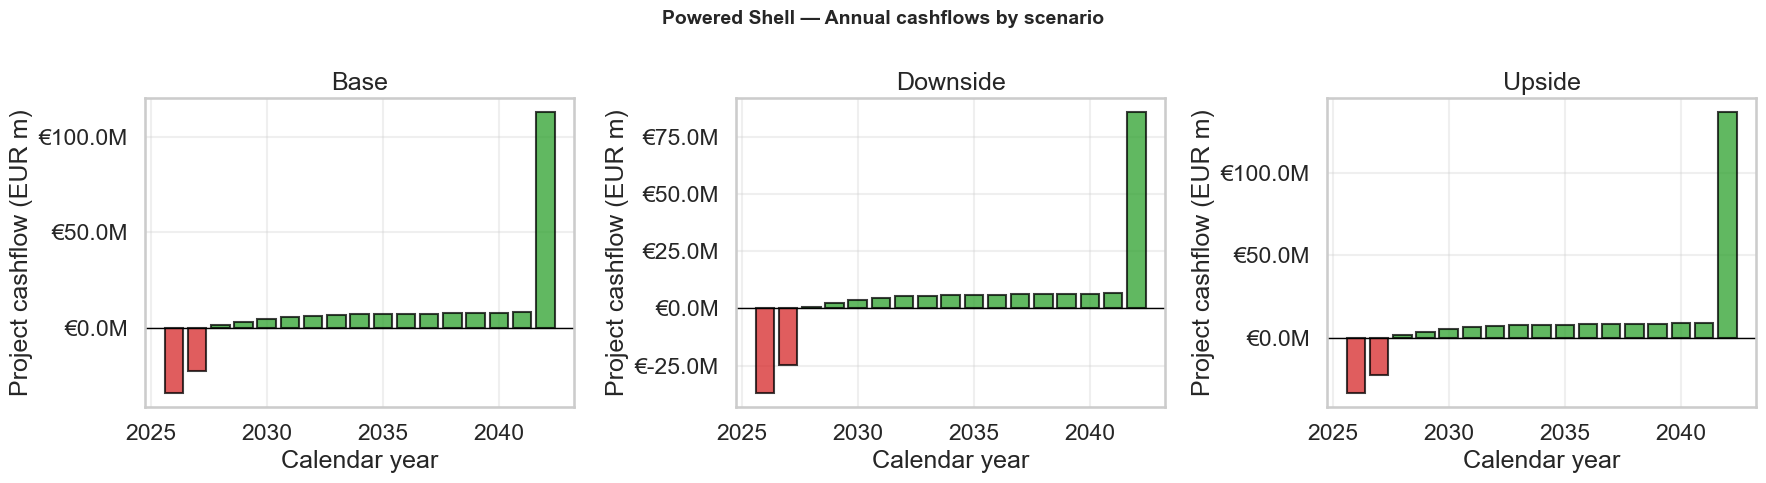

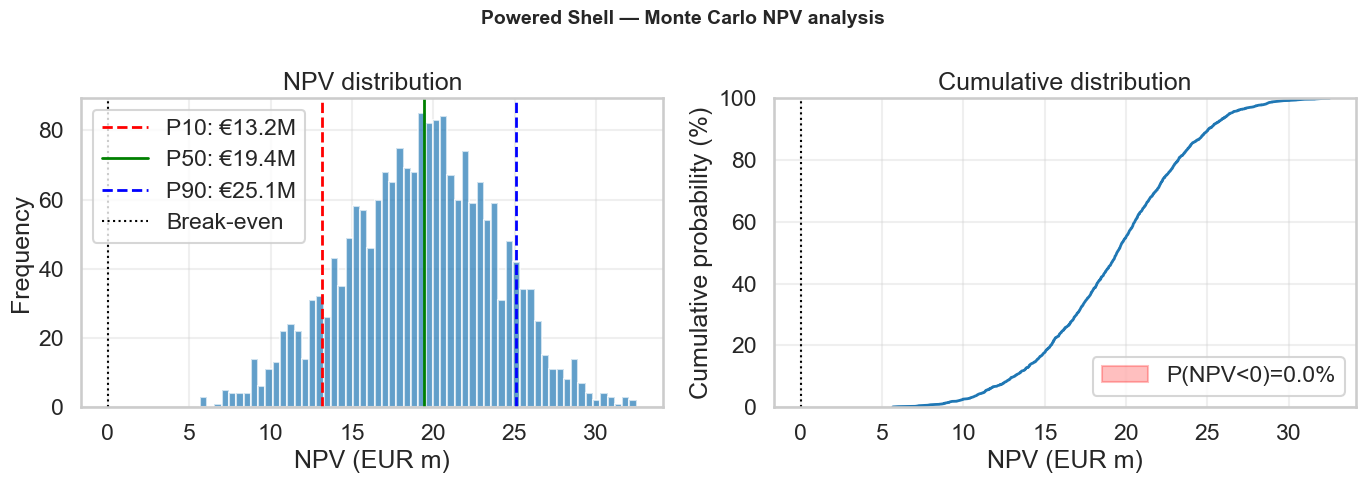

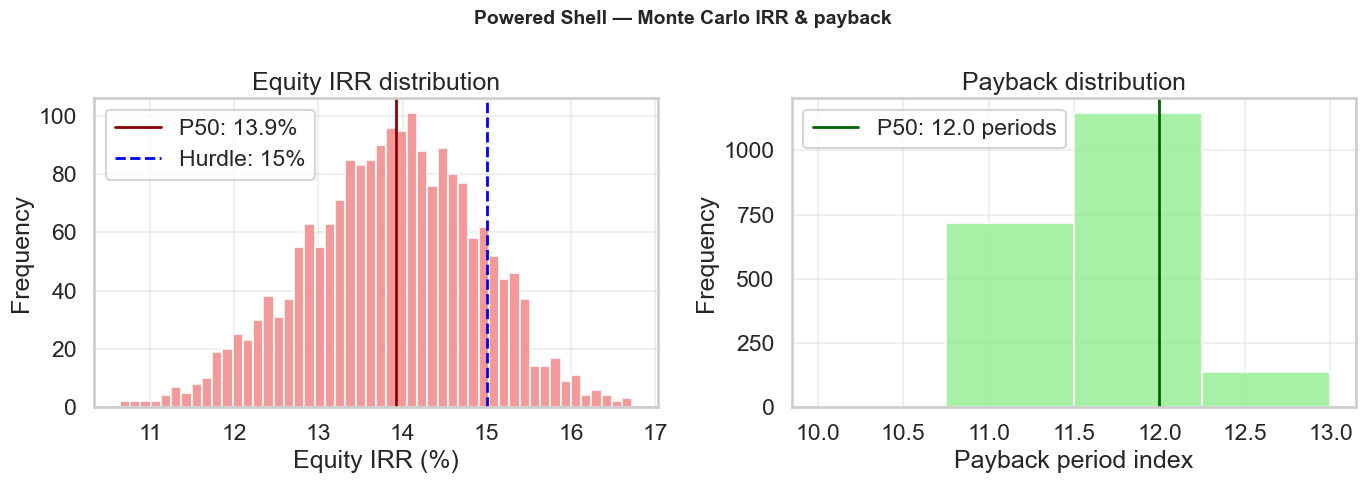

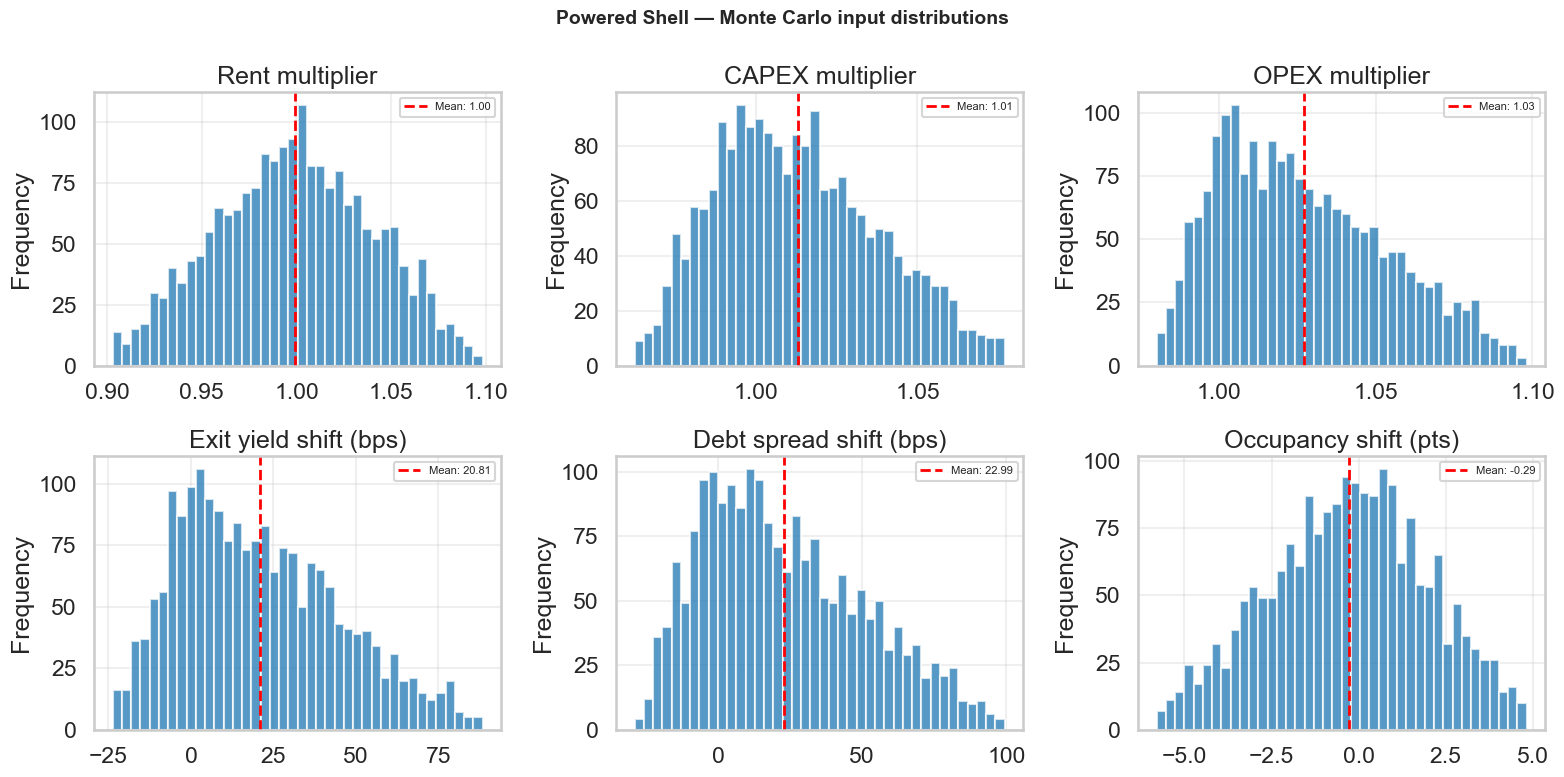

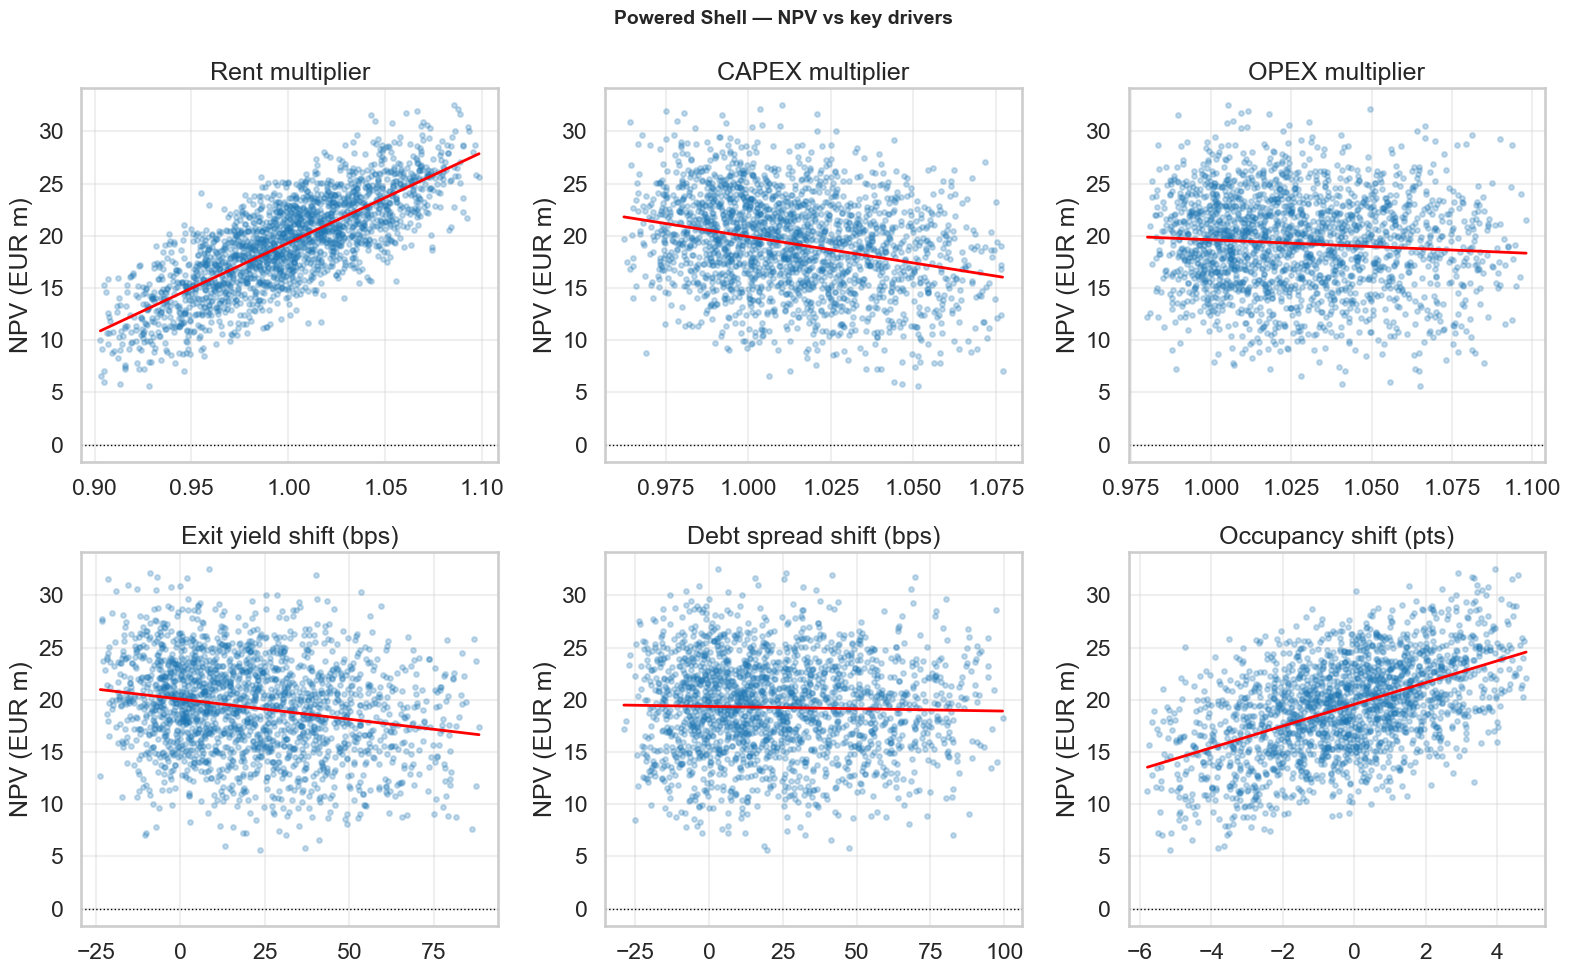

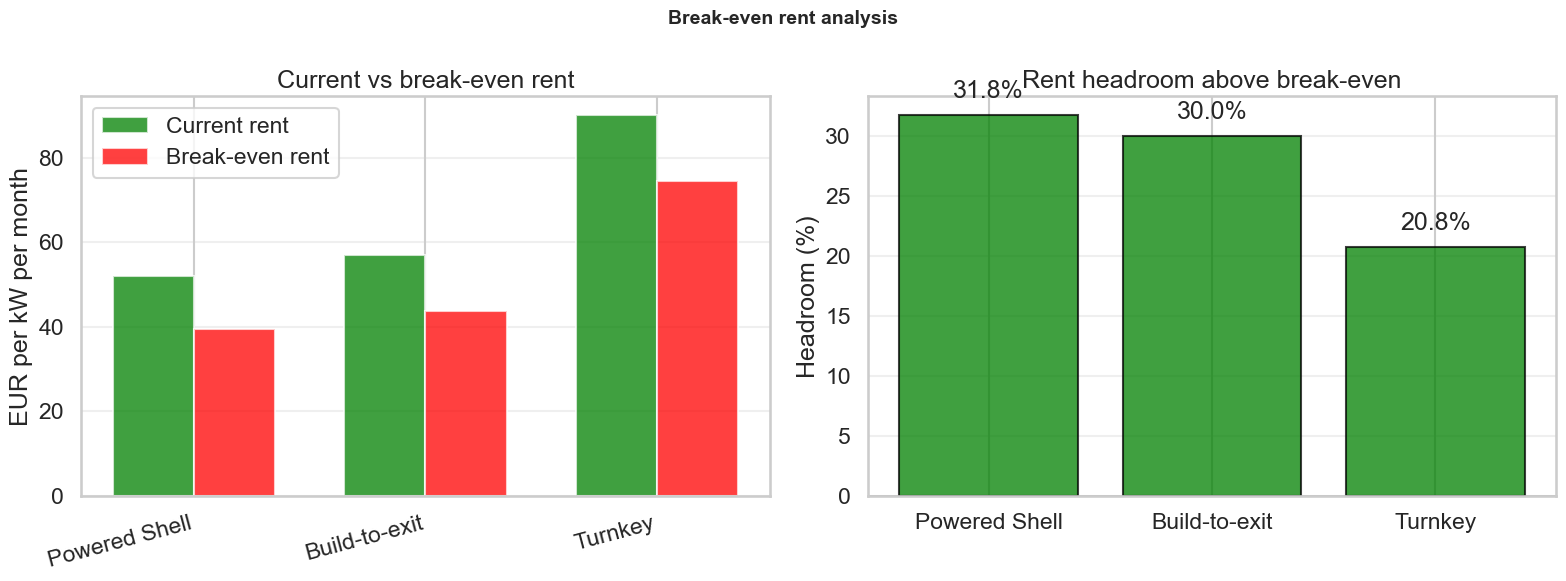

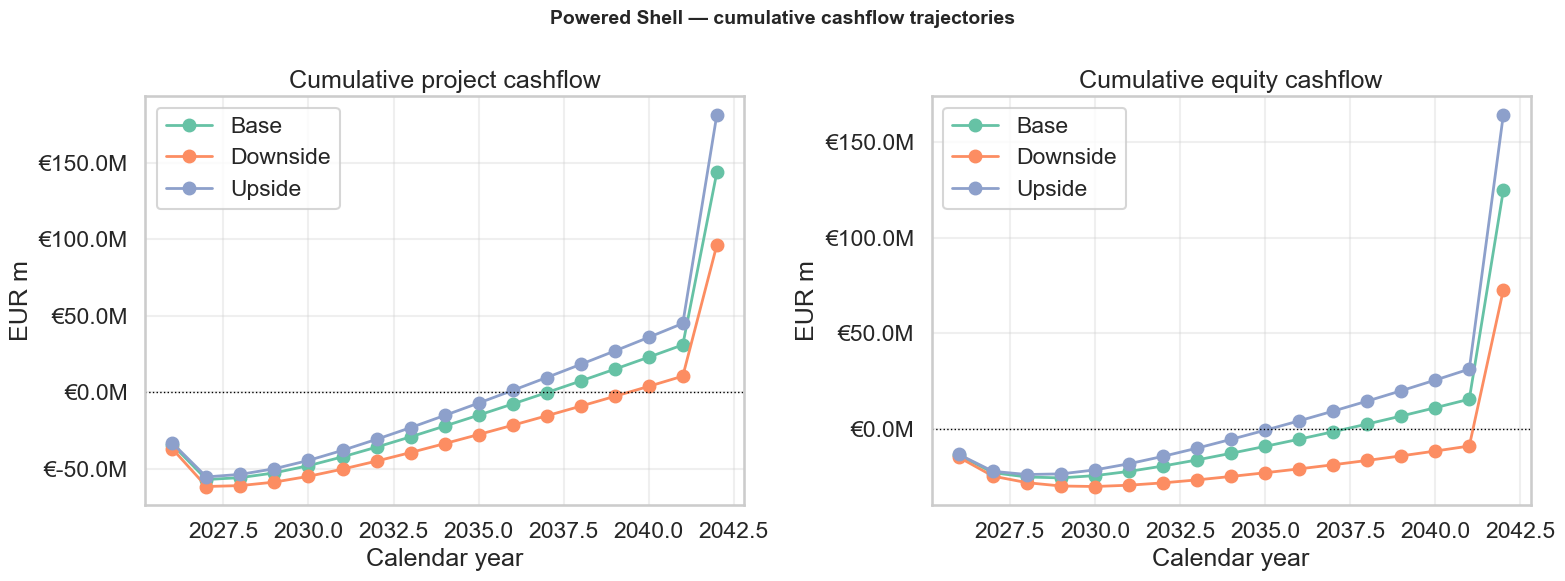

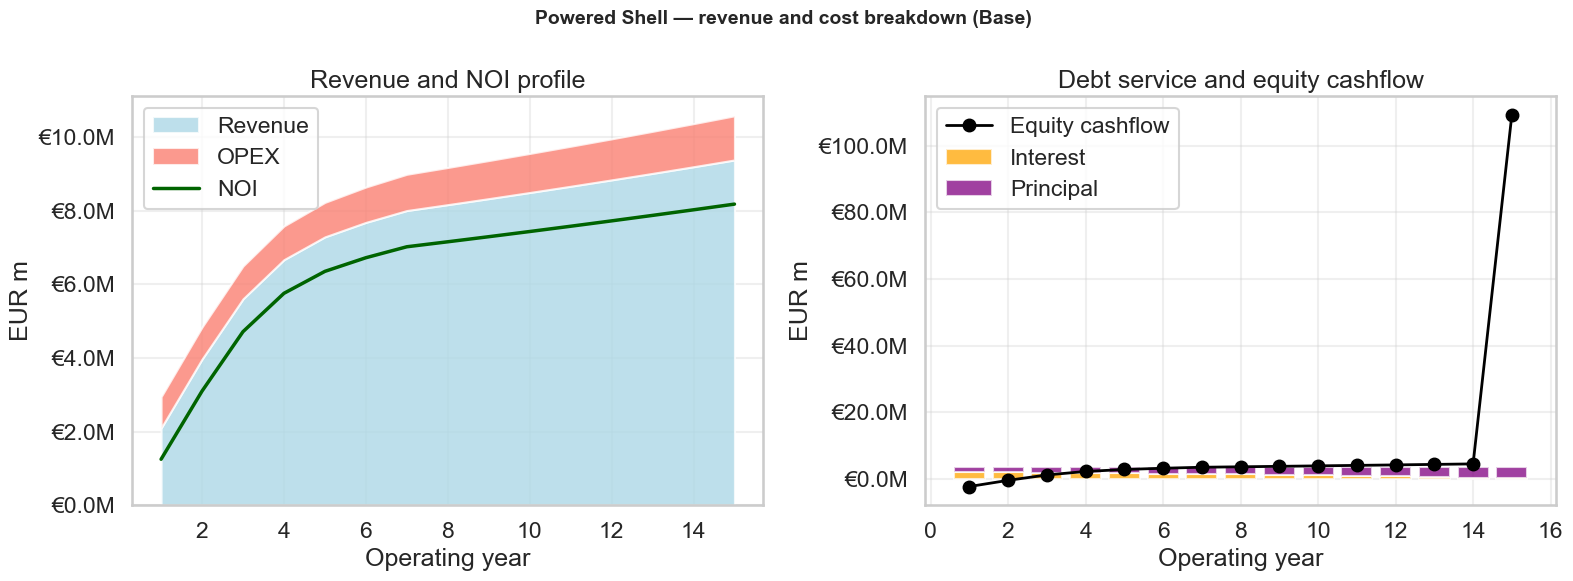

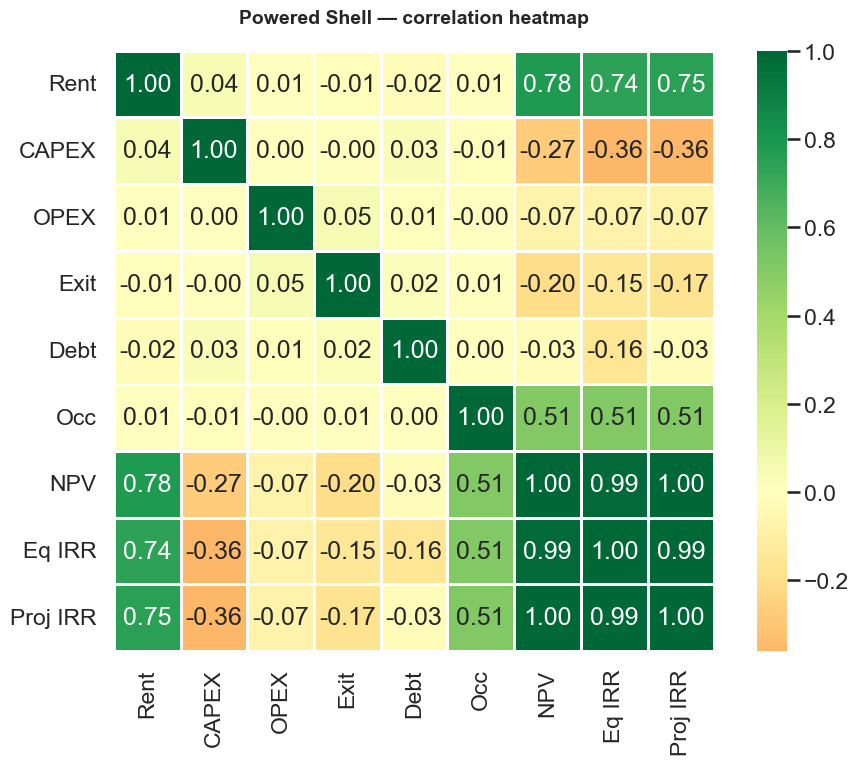

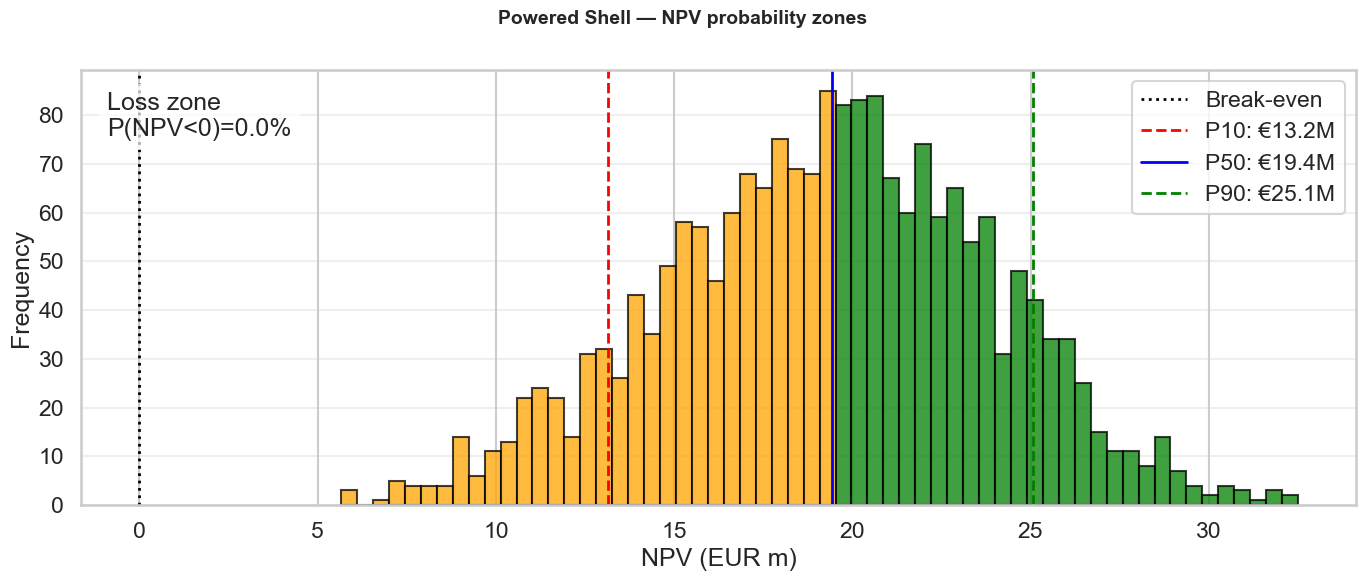

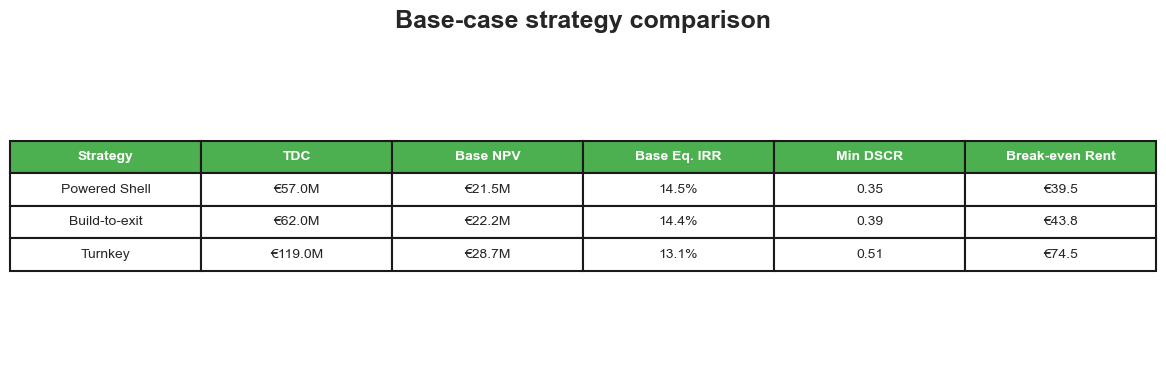

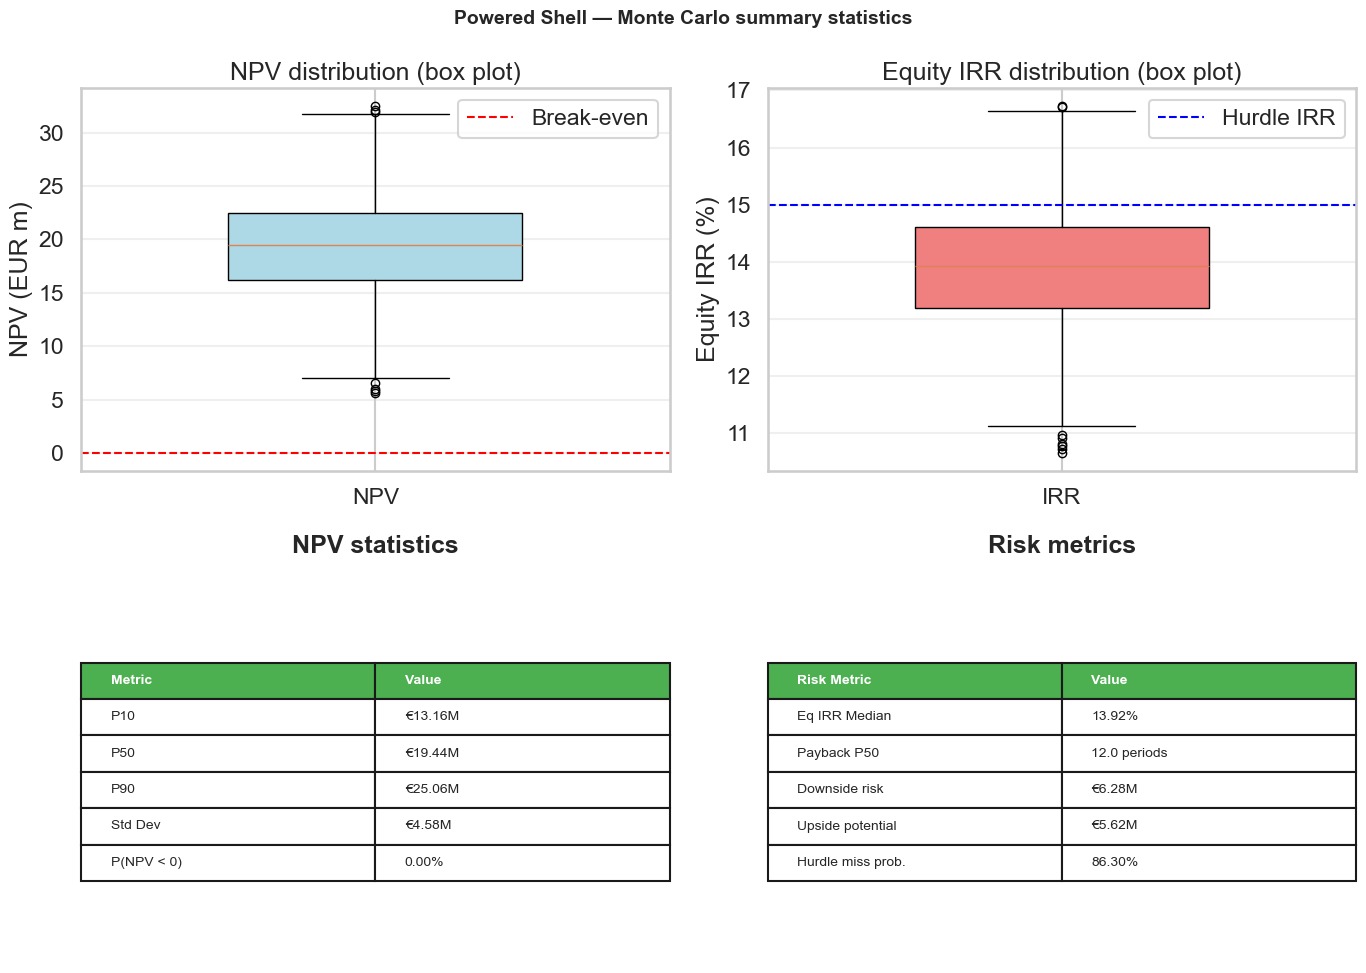

Extended visualization preview complete.


In [5]:
# Extended prototype-style visualization and profiling functions

payback_cache = {}


def _fmt_meur(x, _=None):
    return f'€{x:,.1f}M'


def _fmt_pct(x, _=None):
    return f'{x:.0%}'


def _simple_payback_period(cashflows: np.ndarray) -> float:
    cum = np.cumsum(np.asarray(cashflows, dtype=float))
    idx = np.where(cum >= 0)[0]
    return float(idx[0]) if len(idx) else np.nan


def get_payback_distribution(strategy_name: str) -> np.ndarray:
    if strategy_name not in payback_cache:
        strategy = strategies[strategy_name]
        values = []
        for row in mc_runs[strategy_name].itertuples(index=False):
            scenario = dc.Scenario(
                name='MC',
                rent_multiplier=float(row.rent_mult),
                capex_multiplier=float(row.capex_mult),
                opex_multiplier=float(row.opex_mult),
                exit_yield_shift=float(row.exit_shift),
                debt_cost_shift=float(row.debt_shift),
                occupancy_shift=float(row.occ_shift),
            )
            res = dc.build_detailed_cashflows(strategy, ga, scenario, include_break_even=False)
            values.append(_simple_payback_period(res['project_cf']))
        payback_cache[strategy_name] = np.array(values, dtype=float)
    return payback_cache[strategy_name]


def plot_cashflow_scenarios(strategy_name: str) -> None:
    """Plot annual project cashflows for Base, Downside, and Upside cases."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{strategy_name} — Annual cashflows by scenario', fontsize=14, fontweight='bold')

    for ax, scenario_name in zip(axes, ['Base', 'Downside', 'Upside']):
        df = annual_tables[(strategy_name, scenario_name)]
        values = df['project_cashflow'] / 1e6
        colors = ['#d62728' if x < 0 else '#2ca02c' for x in values]
        ax.bar(df['calendar_year'].astype(int), values, color=colors, alpha=0.75, edgecolor='black')
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(scenario_name)
        ax.set_xlabel('Calendar year')
        ax.set_ylabel('Project cashflow (EUR m)')
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_meur))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_monte_carlo_npv_distribution(strategy_name: str) -> None:
    """Plot NPV histogram and cumulative distribution for one strategy."""
    df = mc_runs[strategy_name]
    s = dc.summarize_mc(df, ga.hurdle_equity_irr)
    npvs = df['npv'].to_numpy() / 1e6

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{strategy_name} — Monte Carlo NPV analysis', fontsize=14, fontweight='bold')

    ax1.hist(npvs, bins=60, color=series_colors[strategy_name], edgecolor='white', alpha=0.7)
    ax1.axvline(s['NPV_P10'] / 1e6, color='red', linestyle='--', linewidth=2, label=f"P10: €{s['NPV_P10']/1e6:.1f}M")
    ax1.axvline(s['NPV_P50'] / 1e6, color='green', linestyle='-', linewidth=2, label=f"P50: €{s['NPV_P50']/1e6:.1f}M")
    ax1.axvline(s['NPV_P90'] / 1e6, color='blue', linestyle='--', linewidth=2, label=f"P90: €{s['NPV_P90']/1e6:.1f}M")
    ax1.axvline(0, color='black', linestyle=':', linewidth=1.5, label='Break-even')
    ax1.set_xlabel('NPV (EUR m)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('NPV distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    sorted_npv = np.sort(npvs)
    cumulative = np.arange(1, len(sorted_npv) + 1) / len(sorted_npv) * 100
    ax2.plot(sorted_npv, cumulative, color=series_colors[strategy_name], linewidth=2)
    ax2.fill_between(sorted_npv, 0, cumulative, where=(sorted_npv < 0), color='red', alpha=0.25, label=f"P(NPV<0)={s['Prob_NPV_lt_0']*100:.1f}%")
    ax2.axvline(0, color='black', linestyle=':', linewidth=1.5)
    ax2.set_xlabel('NPV (EUR m)')
    ax2.set_ylabel('Cumulative probability (%)')
    ax2.set_title('Cumulative distribution')
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_monte_carlo_irr_payback(strategy_name: str) -> None:
    """Plot equity IRR and payback distributions for one strategy."""
    df = mc_runs[strategy_name]
    s = dc.summarize_mc(df, ga.hurdle_equity_irr)
    irrs = df['equity_irr'].dropna().to_numpy() * 100
    paybacks = get_payback_distribution(strategy_name)
    pb_valid = paybacks[~np.isnan(paybacks)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{strategy_name} — Monte Carlo IRR & payback', fontsize=14, fontweight='bold')

    ax1.hist(irrs, bins=50, color='lightcoral', edgecolor='white', alpha=0.8)
    ax1.axvline(s['EqIRR_P50'] * 100, color='darkred', linestyle='-', linewidth=2, label=f"P50: {s['EqIRR_P50']*100:.1f}%")
    ax1.axvline(ga.hurdle_equity_irr * 100, color='blue', linestyle='--', linewidth=2, label=f"Hurdle: {ga.hurdle_equity_irr*100:.0f}%")
    ax1.set_xlabel('Equity IRR (%)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Equity IRR distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if len(pb_valid):
        ax2.hist(pb_valid, bins=min(20, len(np.unique(pb_valid))), color='lightgreen', edgecolor='white', alpha=0.8)
        ax2.axvline(np.nanmedian(pb_valid), color='darkgreen', linestyle='-', linewidth=2, label=f"P50: {np.nanmedian(pb_valid):.1f} periods")
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'No payback reached\nin Monte Carlo sample', ha='center', va='center', fontsize=12)
    ax2.set_xlabel('Payback period index')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Payback distribution')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_input_distributions(strategy_name: str) -> None:
    """Plot Monte Carlo input distributions for one strategy."""
    df = mc_runs[strategy_name].copy()
    df['exit_shift_bps'] = df['exit_shift'] * 10000
    df['debt_shift_bps'] = df['debt_shift'] * 10000
    df['occ_shift_pts'] = df['occ_shift'] * 100

    cols = [
        ('rent_mult', 'Rent multiplier'),
        ('capex_mult', 'CAPEX multiplier'),
        ('opex_mult', 'OPEX multiplier'),
        ('exit_shift_bps', 'Exit yield shift (bps)'),
        ('debt_shift_bps', 'Debt spread shift (bps)'),
        ('occ_shift_pts', 'Occupancy shift (pts)'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f'{strategy_name} — Monte Carlo input distributions', fontsize=14, fontweight='bold')

    for ax, (col, title) in zip(axes.flatten(), cols):
        values = df[col].to_numpy()
        ax.hist(values, bins=40, color=series_colors[strategy_name], edgecolor='white', alpha=0.75)
        ax.axvline(values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {values.mean():.2f}')
        ax.set_title(title)
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_npv_vs_key_drivers(strategy_name: str) -> None:
    """Scatter NPV against the main Monte Carlo drivers."""
    df = mc_runs[strategy_name].copy()
    df['npv_m'] = df['npv'] / 1e6
    df['exit_shift_bps'] = df['exit_shift'] * 10000
    df['debt_shift_bps'] = df['debt_shift'] * 10000
    df['occ_shift_pts'] = df['occ_shift'] * 100

    drivers = [
        ('rent_mult', 'Rent multiplier'),
        ('capex_mult', 'CAPEX multiplier'),
        ('opex_mult', 'OPEX multiplier'),
        ('exit_shift_bps', 'Exit yield shift (bps)'),
        ('debt_shift_bps', 'Debt spread shift (bps)'),
        ('occ_shift_pts', 'Occupancy shift (pts)'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'{strategy_name} — NPV vs key drivers', fontsize=14, fontweight='bold')

    for ax, (col, title) in zip(axes.flatten(), drivers):
        x = df[col].to_numpy()
        y = df['npv_m'].to_numpy()
        ax.scatter(x, y, alpha=0.25, s=12, color=series_colors[strategy_name])
        if np.nanstd(x) > 0:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, p(xs), color='red', linewidth=2)
        ax.axhline(0, color='black', linestyle=':', linewidth=1)
        ax.set_title(title)
        ax.set_ylabel('NPV (EUR m)')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def calculate_breakeven_table() -> pd.DataFrame:
    """Build a break-even comparison table from the scenario summary output."""
    out = scenario_df.copy()
    out['Rent_Headroom_Pct'] = (out['Rent_EUR_per_kW_month'] / out['Break_even_Rent_EUR_per_kW_month'] - 1.0) * 100.0
    out['Occ_Headroom_Pts'] = (out['occupancy_proxy'] if 'occupancy_proxy' in out.columns else np.nan)
    return out[[
        'Strategy', 'Scenario', 'Rent_EUR_per_kW_month', 'Break_even_Rent_EUR_per_kW_month',
        'Break_even_Stabilized_Occupancy', 'Project_NPV_9pct', 'Rent_Headroom_Pct'
    ]]


def plot_breakeven_analysis(df_breakeven: pd.DataFrame) -> None:
    """Visualize current vs break-even rent and pricing headroom."""
    base = df_breakeven[df_breakeven['Scenario'] == 'Base'].copy().set_index('Strategy').loc[strategy_order].reset_index()
    x = np.arange(len(base))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Break-even rent analysis', fontsize=14, fontweight='bold')

    ax1.bar(x - width/2, base['Rent_EUR_per_kW_month'], width, label='Current rent', color='green', alpha=0.75)
    ax1.bar(x + width/2, base['Break_even_Rent_EUR_per_kW_month'], width, label='Break-even rent', color='red', alpha=0.75)
    ax1.set_xticks(x)
    ax1.set_xticklabels(base['Strategy'], rotation=15, ha='right')
    ax1.set_ylabel('EUR per kW per month')
    ax1.set_title('Current vs break-even rent')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    headroom = base['Rent_Headroom_Pct'].to_numpy()
    colors = ['green' if h > 0 else 'red' for h in headroom]
    ax2.bar(base['Strategy'], headroom, color=colors, alpha=0.75, edgecolor='black')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_ylabel('Headroom (%)')
    ax2.set_title('Rent headroom above break-even')
    ax2.grid(True, alpha=0.3, axis='y')

    for idx, value in enumerate(headroom):
        ax2.text(idx, value + (1 if value >= 0 else -1), f'{value:.1f}%', ha='center', va='bottom' if value >= 0 else 'top')

    plt.tight_layout()
    plt.show()


def plot_cumulative_cashflows(strategy_name: str) -> None:
    """Plot cumulative project and equity cashflows across scenarios."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{strategy_name} — cumulative cashflow trajectories', fontsize=14, fontweight='bold')

    for scenario_name, color in zip(['Base', 'Downside', 'Upside'], sns.color_palette('Set2', 3)):
        df = annual_tables[(strategy_name, scenario_name)]
        axes[0].plot(df['calendar_year'], df['cum_project_cf'] / 1e6, marker='o', linewidth=2, label=scenario_name, color=color)
        axes[1].plot(df['calendar_year'], df['cum_equity_cf'] / 1e6, marker='o', linewidth=2, label=scenario_name, color=color)

    axes[0].axhline(0, color='black', linestyle=':', linewidth=1)
    axes[1].axhline(0, color='black', linestyle=':', linewidth=1)
    axes[0].set_title('Cumulative project cashflow')
    axes[1].set_title('Cumulative equity cashflow')
    for ax in axes:
        ax.set_xlabel('Calendar year')
        ax.set_ylabel('EUR m')
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_meur))
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_revenue_cost_breakdown(strategy_name: str, scenario_name: str = 'Base') -> None:
    """Plot revenue and operating/financing cost breakdown for one strategy."""
    df = annual_tables[(strategy_name, scenario_name)]
    ops = df[df['phase'] == 'Operate'].copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{strategy_name} — revenue and cost breakdown ({scenario_name})', fontsize=14, fontweight='bold')

    ax1.stackplot(
        ops['op_year'],
        ops['revenue'] / 1e6,
        ops['opex'] / 1e6,
        labels=['Revenue', 'OPEX'],
        colors=['lightblue', 'salmon'],
        alpha=0.8,
    )
    ax1.plot(ops['op_year'], ops['noi'] / 1e6, color='darkgreen', linewidth=2.5, label='NOI')
    ax1.set_xlabel('Operating year')
    ax1.set_ylabel('EUR m')
    ax1.set_title('Revenue and NOI profile')
    ax1.yaxis.set_major_formatter(FuncFormatter(_fmt_meur))
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2.bar(ops['op_year'], ops['interest'] / 1e6, label='Interest', color='orange', alpha=0.75)
    ax2.bar(ops['op_year'], ops['principal'] / 1e6, bottom=ops['interest'] / 1e6, label='Principal', color='purple', alpha=0.75)
    ax2.plot(ops['op_year'], ops['equity_cashflow'] / 1e6, color='black', marker='o', linewidth=2, label='Equity cashflow')
    ax2.set_xlabel('Operating year')
    ax2.set_ylabel('EUR m')
    ax2.set_title('Debt service and equity cashflow')
    ax2.yaxis.set_major_formatter(FuncFormatter(_fmt_meur))
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_risk_heatmap(strategy_name: str) -> None:
    """Show correlation heatmap for Monte Carlo drivers and key outputs."""
    df = mc_runs[strategy_name].copy()
    corr_df = pd.DataFrame({
        'Rent': df['rent_mult'],
        'CAPEX': df['capex_mult'],
        'OPEX': df['opex_mult'],
        'Exit': df['exit_shift'] * 10000,
        'Debt': df['debt_shift'] * 10000,
        'Occ': df['occ_shift'] * 100,
        'NPV': df['npv'] / 1e6,
        'Eq IRR': df['equity_irr'] * 100,
        'Proj IRR': df['project_irr'] * 100,
    })

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=1, ax=ax)
    ax.set_title(f'{strategy_name} — correlation heatmap', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


def plot_npv_probability_zones(strategy_name: str) -> None:
    """Plot NPV distribution with colored loss/base/upside zones."""
    df = mc_runs[strategy_name]
    s = dc.summarize_mc(df, ga.hurdle_equity_irr)
    npvs = df['npv'].to_numpy() / 1e6

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{strategy_name} — NPV probability zones', fontsize=14, fontweight='bold')

    counts, bins, patches = ax.hist(npvs, bins=60, edgecolor='black', alpha=0.75)
    for i, patch in enumerate(patches):
        center = 0.5 * (bins[i] + bins[i + 1])
        if center < 0:
            patch.set_facecolor('red')
        elif center < s['NPV_P50'] / 1e6:
            patch.set_facecolor('orange')
        else:
            patch.set_facecolor('green')

    ax.axvline(0, color='black', linestyle=':', linewidth=2, label='Break-even')
    ax.axvline(s['NPV_P10'] / 1e6, color='red', linestyle='--', linewidth=2, label=f"P10: €{s['NPV_P10']/1e6:.1f}M")
    ax.axvline(s['NPV_P50'] / 1e6, color='blue', linestyle='-', linewidth=2, label=f"P50: €{s['NPV_P50']/1e6:.1f}M")
    ax.axvline(s['NPV_P90'] / 1e6, color='green', linestyle='--', linewidth=2, label=f"P90: €{s['NPV_P90']/1e6:.1f}M")
    ax.text(0.02, 0.95, f"Loss zone\nP(NPV<0)={s['Prob_NPV_lt_0']*100:.1f}%", transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.set_xlabel('NPV (EUR m)')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


def plot_scenario_comparison_table() -> None:
    """Create a visual summary table for the base case across strategies."""
    base = scenario_df[scenario_df['Scenario'] == 'Base'].copy().set_index('Strategy').loc[strategy_order].reset_index()

    rows = []
    for _, row in base.iterrows():
        rows.append([
            row['Strategy'],
            f"€{row['TDC_EUR']/1e6:.1f}M",
            f"€{row['Project_NPV_9pct']/1e6:.1f}M",
            f"{row['Equity_IRR']:.1%}",
            f"{row['Min_DSCR']:.2f}",
            f"€{row['Break_even_Rent_EUR_per_kW_month']:.1f}",
        ])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    table = ax.table(
        cellText=rows,
        colLabels=['Strategy', 'TDC', 'Base NPV', 'Base Eq. IRR', 'Min DSCR', 'Break-even Rent'],
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.0)
    for i in range(6):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    ax.set_title('Base-case strategy comparison', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


def plot_monte_carlo_summary_stats(strategy_name: str) -> None:
    """Show boxplots and summary tables for one strategy's Monte Carlo output."""
    df = mc_runs[strategy_name]
    s = dc.summarize_mc(df, ga.hurdle_equity_irr)
    npvs = df['npv'].to_numpy() / 1e6
    irrs = df['equity_irr'].dropna().to_numpy() * 100
    paybacks = get_payback_distribution(strategy_name)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{strategy_name} — Monte Carlo summary statistics', fontsize=14, fontweight='bold')

    bp1 = axes[0, 0].boxplot([npvs], vert=True, patch_artist=True, widths=0.5)
    bp1['boxes'][0].set_facecolor('lightblue')
    axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
    axes[0, 0].set_ylabel('NPV (EUR m)')
    axes[0, 0].set_title('NPV distribution (box plot)')
    axes[0, 0].set_xticklabels(['NPV'])
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    bp2 = axes[0, 1].boxplot([irrs], vert=True, patch_artist=True, widths=0.5)
    bp2['boxes'][0].set_facecolor('lightcoral')
    axes[0, 1].axhline(ga.hurdle_equity_irr * 100, color='blue', linestyle='--', linewidth=1.5, label='Hurdle IRR')
    axes[0, 1].set_ylabel('Equity IRR (%)')
    axes[0, 1].set_title('Equity IRR distribution (box plot)')
    axes[0, 1].set_xticklabels(['IRR'])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    axes[1, 0].axis('off')
    npv_stats = [
        ['Metric', 'Value'],
        ['P10', f"€{s['NPV_P10']/1e6:.2f}M"],
        ['P50', f"€{s['NPV_P50']/1e6:.2f}M"],
        ['P90', f"€{s['NPV_P90']/1e6:.2f}M"],
        ['Std Dev', f"€{np.std(npvs):.2f}M"],
        ['P(NPV < 0)', f"{s['Prob_NPV_lt_0']*100:.2f}%"],
    ]
    table1 = axes[1, 0].table(cellText=npv_stats, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
    table1.auto_set_font_size(False)
    table1.set_fontsize(10)
    table1.scale(1, 2)
    for i in range(2):
        table1[(0, i)].set_facecolor('#4CAF50')
        table1[(0, i)].set_text_props(weight='bold', color='white')
    axes[1, 0].set_title('NPV statistics', fontweight='bold', pad=20)

    axes[1, 1].axis('off')
    pb_valid = paybacks[~np.isnan(paybacks)]
    risk_stats = [
        ['Risk Metric', 'Value'],
        ['Eq IRR Median', f"{s['EqIRR_P50']*100:.2f}%"],
        ['Payback P50', f"{np.nanmedian(pb_valid):.1f} periods" if len(pb_valid) else 'N/A'],
        ['Downside risk', f"€{(s['NPV_P50'] - s['NPV_P10'])/1e6:.2f}M"],
        ['Upside potential', f"€{(s['NPV_P90'] - s['NPV_P50'])/1e6:.2f}M"],
        ['Hurdle miss prob.', f"{s['Prob_EqIRR_lt_Hurdle']*100:.2f}%"],
    ]
    table2 = axes[1, 1].table(cellText=risk_stats, cellLoc='left', loc='center', colWidths=[0.5, 0.5])
    table2.auto_set_font_size(False)
    table2.set_fontsize(10)
    table2.scale(1, 2)
    for i in range(2):
        table2[(0, i)].set_facecolor('#4CAF50')
        table2[(0, i)].set_text_props(weight='bold', color='white')
    axes[1, 1].set_title('Risk metrics', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()


print('Extended prototype-style visualization functions loaded for the detailed cashflow notebook.')
print('Available helpers:')
for fn in [
    'plot_cashflow_scenarios',
    'plot_monte_carlo_npv_distribution',
    'plot_monte_carlo_irr_payback',
    'plot_input_distributions',
    'plot_npv_vs_key_drivers',
    'calculate_breakeven_table',
    'plot_breakeven_analysis',
    'plot_cumulative_cashflows',
    'plot_revenue_cost_breakdown',
    'plot_risk_heatmap',
    'plot_npv_probability_zones',
    'plot_scenario_comparison_table',
    'plot_monte_carlo_summary_stats',
]:
    print(f' - {fn}')
# Preview of the extended prototype-style plotting suite
focus_strategy = best['Strategy']
print(f'Generating extended prototype-style visuals for: {focus_strategy}')

plot_cashflow_scenarios(focus_strategy)
plot_monte_carlo_npv_distribution(focus_strategy)
plot_monte_carlo_irr_payback(focus_strategy)
plot_input_distributions(focus_strategy)
plot_npv_vs_key_drivers(focus_strategy)
plot_breakeven_analysis(calculate_breakeven_table())
plot_cumulative_cashflows(focus_strategy)
plot_revenue_cost_breakdown(focus_strategy)
plot_risk_heatmap(focus_strategy)
plot_npv_probability_zones(focus_strategy)
plot_scenario_comparison_table()
plot_monte_carlo_summary_stats(focus_strategy)

print('Extended visualization preview complete.')